# Modeling, Calibration & Decision Layer

Loads the prepared feature matrix and runs the full modeling pipeline: a
leak-free time-aware backtest, baselines, a global LightGBM model, calibrated
prediction intervals, a cost-aware ordering layer, and SHAP explainability.

In [1]:
import sys; sys.path.append('..')
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.statespace.sarimax import SARIMAX
import joblib
import shap
from itertools import product
from src.model import score_params, train_quantile_models
from src.backtest import expanding_window_splits
from src.metrics import mase, seasonal_naive_scale, seasonal_naive_pred
from src.decision import total_cost, service_level

model_df = pd.read_pickle('../data/model_df.pkl')

## Leakage sanity check

Confirm `lag_7` equals sales from 7 days earlier and the rolling mean uses only
prior days — a manual check that the features look only backward.

In [2]:
# Verify lag_7 really equals sales from 7 days earlier
# rolling mean uses only prior days

one = model_df[model_df['id'] == model_df['id'].iloc[0]].head(20)
one[['date', 'sales', 'lag_7', 'rolling_mean_7', 'rolling_std_7']]

,date,sales,lag_7,rolling_mean_7,rolling_std_7
0,2011-02-26,2,1.0,1.857143,1.214986
1,2011-02-27,2,2.0,2.000000,1.154701
2,2011-02-28,0,0.0,2.000000,1.154701
3,2011-03-01,2,2.0,2.000000,1.154701
4,2011-03-02,1,2.0,2.000000,1.154701
5,2011-03-03,7,2.0,1.857143,1.214986
6,2011-03-04,1,4.0,2.571429,2.299068
7,2011-03-05,2,2.0,2.142857,2.267787
8,2011-03-06,3,2.0,2.142857,2.267787
9,2011-03-07,0,0.0,2.285714,2.288689


In [3]:
feature_cols = (
    [f'lag_{l}' for l in (7, 14, 28)]
    + [f'rolling_mean_{w}' for w in (7, 28)]
    + [f'rolling_std_{w}' for w in (7, 28)]
    + ['wday', 'month', 'is_event', 'snap', 'day', 'sell_price']
)

before = len(model_df)

#Drop rows with NaN features (first 28 days of each series, plus any missing prices)
model_df = model_df.dropna(subset=feature_cols).reset_index(drop=True)
print(f"Dropped {before - len(model_df)} rows with NaN features; {len(model_df)} remain.")
print(f"Feature columns: {feature_cols}")

Dropped 0 rows with NaN features; 2241684 remain.
Feature columns: ['lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_28', 'rolling_std_7', 'rolling_std_28', 'wday', 'month', 'is_event', 'snap', 'day', 'sell_price']


## Time-aware backtest & seasonal-naive baseline

An expanding-window backtest (train on the past, test on the next 28 days, slide
forward) — never a random split. The seasonal-naive baseline (last week's sales)
is the reference every model must beat, scored with MASE.

In [4]:
for i, (train_idx, test_idx) in enumerate(expanding_window_splits(model_df)):
    tr, te = model_df.loc[train_idx], model_df.loc[test_idx]
    print(f"Fold {i}:")
    print(f"  train {tr['date'].min().date()} → {tr['date'].max().date()}  ({len(tr):,} rows)")
    print(f"  test  {te['date'].min().date()} → {te['date'].max().date()}  ({len(te):,} rows)")
    print()

Fold 0:
  train 2011-02-26 → 2016-04-24  (2,201,448 rows)
  test  2016-04-25 → 2016-05-22  (40,236 rows)

Fold 1:
  train 2011-02-26 → 2016-03-27  (2,161,212 rows)
  test  2016-03-28 → 2016-04-24  (40,236 rows)

Fold 2:
  train 2011-02-26 → 2016-02-28  (2,120,976 rows)
  test  2016-02-29 → 2016-03-27  (40,236 rows)



In [5]:
for i, (train_idx, test_idx) in enumerate(expanding_window_splits(model_df)):
    tr, te = model_df.loc[train_idx], model_df.loc[test_idx]
    scale = seasonal_naive_scale(tr)
    score = mase(te['sales'].values, seasonal_naive_pred(te).values, scale)
    print(f"Fold {i}: seasonal-naive MASE = {score:.3f}")

Fold 0: seasonal-naive MASE = 0.948
Fold 1: seasonal-naive MASE = 0.907
Fold 2: seasonal-naive MASE = 0.868


## Classical baseline (SARIMA)

Fit SARIMA on the three highest-volume series as a "model family" comparison.
It modestly beats seasonal-naive on these easy series but cannot scale to all
1,437 or use covariates — motivating the global ML approach.

In [6]:
# Picking the 3 highest-volume series to keep the example small and fast. You can try more series, but it will take longer.
top_ids = (model_df.groupby('id')['sales'].sum()
           .sort_values(ascending=False).head(3).index.tolist())

Horizon = 28
results = []

for sid in top_ids:
    s = model_df[model_df['id'] == sid].sort_values('date')
    y = s['sales'].values
    train, test = y[:-Horizon], y[-Horizon:]

    # simple weekly-seasonal spec
    model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,7),
                    enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)
    fcst = fit.forecast(steps=Horizon)

    #MASE using the per-series seasonal-naive scale on this series
    scale = np.mean(np.abs(train[7:] - train[:-7]))
    score = np.mean(np.abs(test - fcst)) / scale if scale != 0 else np.nan
    results.append((sid, score))
    print(f"{sid}: SARIMA MASE = {score: .3f}")

print("Per-series comparison (same series, same scaling):")
for sid in top_ids:
    s = model_df[model_df['id'] == sid].sort_values('date')
    y = s['sales'].values
    train, test = y[:-Horizon], y[-Horizon:]
    scale = np.mean(np.abs(train[7:] - train[:-7]))

    # seasonal-naive forecast for the 28-day test window = value 7 days earlier
    naive_fcst = y[-Horizon-7:-7]
    naive_mase = np.mean(np.abs(test - naive_fcst)) / scale
    print(f"{sid}: seasonal-naive MASE = {naive_mase:.3f}")

print("\nMean SARIMA MASE:", np.nanmean([r[1] for r in results]))   

FOODS_3_090_CA_1_evaluation: SARIMA MASE =  0.428
FOODS_3_586_CA_1_evaluation: SARIMA MASE =  0.606
FOODS_3_252_CA_1_evaluation: SARIMA MASE =  0.603
Per-series comparison (same series, same scaling):
FOODS_3_090_CA_1_evaluation: seasonal-naive MASE = 0.510
FOODS_3_586_CA_1_evaluation: seasonal-naive MASE = 0.716
FOODS_3_252_CA_1_evaluation: seasonal-naive MASE = 0.721

Mean SARIMA MASE: 0.545717394660517


## Global models: LightGBM & XGBoost

One model across all series, using the engineered features, evaluated on the same
folds and scaling as the baseline.

In [7]:
# --- Feature setup ---
# Categorical features LightGBM should treat as such
cat_features = ['dept_id', 'wday', 'month']
# Make sure categoricals are 'category' dtype
for c in cat_features:
    model_df[c] = model_df[c].astype('category')

# Full feature list: your engineered features + categoricals
features = (
    ['lag_7', 'lag_14', 'lag_28',
     'rolling_mean_7', 'rolling_std_7', 'rolling_mean_28', 'rolling_std_28',
     'day', 'is_event', 'snap', 'sell_price']
    + cat_features
)
target = 'sales'

In [8]:
def run_backtest(model_name):
    """Train one model type across the expanding-window folds, return MASE per fold."""
    scores = []
    for i, (train_idx, test_idx) in enumerate(expanding_window_splits(model_df)):
        tr, te = model_df.loc[train_idx], model_df.loc[test_idx]
        X_tr, y_tr = tr[features], tr[target]
        X_te, y_te = te[features], te[target]

        if model_name == 'lightgbm':
            model = lgb.LGBMRegressor(
                n_estimators=300, learning_rate=0.05,
                num_leaves=63, n_jobs=-1, verbose=-1
            )
            model.fit(X_tr, y_tr, categorical_feature=cat_features)
        else:  # xgboost
            model = xgb.XGBRegressor(
                n_estimators=300, learning_rate=0.05,
                max_depth=6, n_jobs=-1, enable_categorical=True
            )
            model.fit(X_tr, y_tr)

        pred = model.predict(X_te)
        pred = np.clip(pred, 0, None)  # sales can't be negative

        scale = seasonal_naive_scale(tr)        # same scale as the baseline
        score = np.mean(np.abs(y_te.values - pred)) / scale
        scores.append(score)
        print(f"  Fold {i}: MASE = {score:.3f}")
    print(f"  Mean MASE = {np.mean(scores):.3f}\n")
    return scores

print("LightGBM:")
lgbm_scores = run_backtest('lightgbm')

print("XGBoost:")
xgb_scores  = run_backtest('xgboost')

LightGBM:
  Fold 0: MASE = 0.742
  Fold 1: MASE = 0.709
  Fold 2: MASE = 0.694
  Mean MASE = 0.715

XGBoost:
  Fold 0: MASE = 0.745
  Fold 1: MASE = 0.710
  Fold 2: MASE = 0.695
  Mean MASE = 0.716



In [9]:
print(f"{'Model':<22}{'Mean MASE':>10}")
print("-" * 32)
print(f"{'Seasonal-naive (all)':<22}{0.908:>10.3f}")   
print(f"{'LightGBM (global)':<22}{np.mean(lgbm_scores):>10.3f}")
print(f"{'XGBoost (global)':<22}{np.mean(xgb_scores):>10.3f}")

Model                  Mean MASE
--------------------------------
Seasonal-naive (all)       0.908
LightGBM (global)          0.715
XGBoost (global)           0.716


## Tuning & final model

A light, time-aware tuning pass (each candidate scored on the backtest, not a
random split), then refit on all data and save with joblib.

In [12]:
# A small, sensible search space — light, not exhaustive
candidates = [
    {'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 31},
    {'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 63},
    {'n_estimators': 500, 'learning_rate': 0.03, 'num_leaves': 63},
    {'n_estimators': 800, 'learning_rate': 0.03, 'num_leaves': 127},
]

results = [
    (p, score_params(model_df, p, features, target, cat_features,
                     expanding_window_splits, seasonal_naive_scale))
    for p in candidates
]
for p, s in sorted(results, key=lambda x: x[1]):
    print(f"MASE {s:.3f}  ←  {p}")

best_params = min(results, key=lambda x: x[1])[0]
print("\nBest:", best_params)

MASE 0.713  ←  {'n_estimators': 800, 'learning_rate': 0.03, 'num_leaves': 127}
MASE 0.714  ←  {'n_estimators': 500, 'learning_rate': 0.05, 'num_leaves': 63}
MASE 0.716  ←  {'n_estimators': 500, 'learning_rate': 0.03, 'num_leaves': 63}
MASE 0.718  ←  {'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 31}

Best: {'n_estimators': 800, 'learning_rate': 0.03, 'num_leaves': 127}


In [13]:
final_model = lgb.LGBMRegressor(**best_params, n_jobs = -1, verbose =-1)
final_model.fit(model_df[features], model_df[target], categorical_feature= cat_features)

joblib.dump(final_model, '../models/lgbm_final.joblib')
print("Saved to models/lgbm_final.joblib")

Saved to models/lgbm_final.joblib


## Probabilistic forecasting

Train one LightGBM per quantile (10th/50th/90th) to form prediction intervals,
evaluated with pinball loss.

In [14]:
# Train on the first fold training data
train_idx, test_idx = next(expanding_window_splits(model_df))
tr, te = model_df.loc[train_idx], model_df.loc[test_idx]

qmodels = train_quantile_models(tr, features, target, cat_features)

# Predict all three quartiles on the test set
preds = {q: np.clip(m.predict(te[features]), 0, None) for q, m in qmodels.items()}

# Look at a few rows: low / median / high

inspect = pd.DataFrame({
    'actual': te[target].values,
    'q10': preds[0.1],
    'q50': preds[0.5],
    'q90': preds[0.9],
}).head(15)
print(inspect)

    actual  q10       q50       q90
0        2  0.0  1.000000  2.673267
1        0  0.0  1.000000  2.310140
2        0  0.0  1.000000  2.317273
3        0  0.0  1.000000  2.384120
4        0  0.0  1.000000  2.828286
5        1  0.0  0.959275  2.628035
6        1  0.0  0.959275  2.381184
7        0  0.0  0.724288  2.701436
8        6  0.0  0.239043  2.129795
9        1  0.0  1.000000  2.529742
10       0  0.0  0.785836  2.192118
11       3  0.0  1.000000  2.690012
12       0  0.0  1.000000  3.425827
13       0  0.0  1.000000  2.514265
14       0  0.0  0.954875  2.520348


In [15]:
def pinball_loss(y_true, y_pred, q):
    # Pinball loss for quantile q

    diff = y_true - y_pred
    return np.mean(np.maximum(q*diff, (q-1)*diff))

quantiles = (0.1,0.5,0.9)
#{quantile:[fold0_loss, fold1_loss, fold2_loss]
pinball_by_q = {q: [] for q in quantiles}

for train_idx, test_idx in expanding_window_splits(model_df):
    tr, te = model_df.loc[train_idx], model_df.loc[test_idx]
    qmodels = train_quantile_models(tr, features, target, cat_features, quantiles=quantiles)

    for q in quantiles:
        pred = np.clip(qmodels[q].predict(te[features]),0,None)
        pinball_by_q[q].append(pinball_loss(te[target].values, pred, q))

# Mean pinball loss per quantile across folds
mean_pinball = {q: np.mean(v) for q, v in pinball_by_q.items()}
for q, loss in mean_pinball.items():
    print(f"q{int(q*100)} : mean pinball loss = {loss: .4f}")

q10 : mean pinball loss =  0.1932
q50 : mean pinball loss =  0.6281
q90 : mean pinball loss =  0.3763


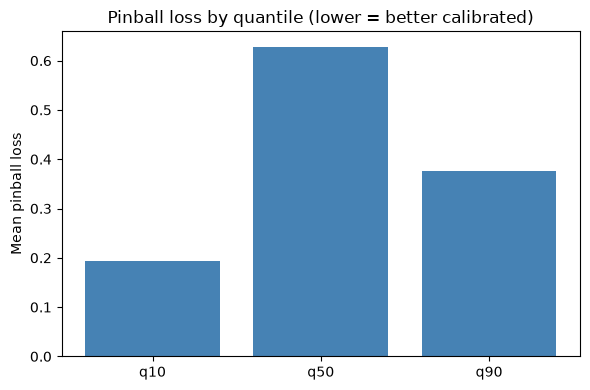

In [16]:
plt.figure(figsize=(6,4))
qs = list(mean_pinball.keys())
losses = list(mean_pinball.values())
plt.bar([f"q{int(q*100)}" for q in qs], losses, color ='steelblue')
plt.ylabel("Mean pinball loss")
plt.title("Pinball loss by quantile (lower = better calibrated)")
plt.tight_layout()
plt.savefig('../reports/figures/pinball_loss_by_quantile.png', dpi=120)
plt.show()

## Interval calibration

Does a nominal 90% interval actually cover ~90%? Measure empirical coverage and
attempt recalibration. (Coverage is conservative at ~95%, structurally bounded by
zero-inflation — see README.)

In [17]:
quantiles = (0.05, 0.5, 0.95)
nominal = 0.95 - 0.05  # 90% interval

coverages, widths = [], []
qmodels_per_fold = []   # <-- this is what the recalibration needs

for train_idx, test_idx in expanding_window_splits(model_df):
    tr, te = model_df.loc[train_idx], model_df.loc[test_idx]
    qm = train_quantile_models(tr, features, target, cat_features, quantiles=quantiles)
    qmodels_per_fold.append((qm, test_idx))      # store model + which rows it was tested on
    lo = np.clip(qm[0.05].predict(te[features]), 0, None)
    hi = np.clip(qm[0.95].predict(te[features]), 0, None)
    actual = te[target].values
    coverages.append(((actual >= lo) & (actual <= hi)).mean())
    widths.append(np.mean(hi - lo))

emp_before = np.mean(coverages)
print(f"Nominal: {nominal:.0%} | Empirical (before): {emp_before:.1%}")
print(f"Per-fold: {[f'{c:.1%}' for c in coverages]}")
print(f"Mean interval width: {np.mean(widths):.2f}")

Nominal: 90% | Empirical (before): 94.8%
Per-fold: ['94.5%', '95.1%', '94.8%']
Mean interval width: 5.28


In [18]:
def coverage_at_scale(qm, test_idx, scale):
    te = model_df.loc[test_idx]
    med = np.clip(qm[0.5].predict(te[features]), 0, None)
    lo  = np.clip(qm[0.05].predict(te[features]), 0, None)
    hi  = np.clip(qm[0.95].predict(te[features]), 0, None)
    # shrink/expand around the median
    lo_s = np.clip(med - scale * (med - lo), 0, None)
    hi_s = med + scale * (hi - med)
    actual = te[target].values
    return ((actual >= lo_s) & (actual <= hi_s)).mean()

# Calibrate scale on fold 0 to hit 0.90
qm0, idx0 = qmodels_per_fold[0]
scales = np.linspace(0.3, 1.0, 36)
best_scale = min(scales, key=lambda s: abs(coverage_at_scale(qm0, idx0, s) - 0.90))
print(f"Calibrated scale factor (on fold 0): {best_scale:.2f}")

# Apply to the held-out later folds and measure
after = [coverage_at_scale(qm, idx, best_scale) for qm, idx in qmodels_per_fold[1:]]
emp_after = np.mean(after)
print(f"Empirical (after, held-out folds): {emp_after:.1%}")

Calibrated scale factor (on fold 0): 1.00
Empirical (after, held-out folds): 95.0%


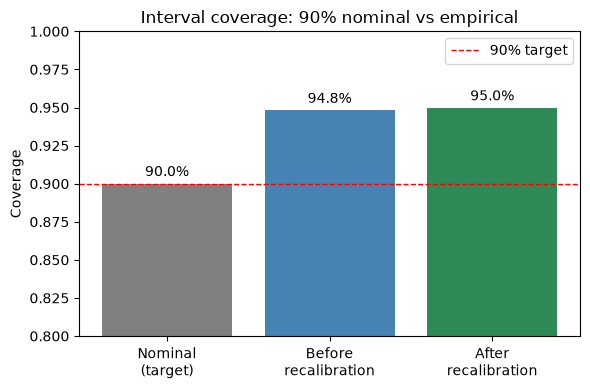

In [19]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Nominal\n(target)', 'Before\nrecalibration', 'After\nrecalibration']
values = [0.90, emp_before, emp_after]
colors = ['gray', 'steelblue', 'seagreen']
bars = ax.bar(labels, values, color=colors)
ax.axhline(0.90, color='red', linestyle='--', linewidth=1, label='90% target')
ax.set_ylabel("Coverage")
ax.set_ylim(0.80, 1.0)
ax.set_title("Interval coverage: 90% nominal vs empirical")
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.1%}", ha='center')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/coverage_calibration.png', dpi=120)
plt.show()


## Cost-aware ordering (newsvendor)

Convert the forecast distribution into an order quantity at the critical-ratio
quantile, and compare cost and service level against ordering the mean.

In [20]:
# Cost setup

Cu = 3.0
Co = 1.0
critical_ratio = Cu/(Cu+Co)
print(f'Critical Ratio (order quantile): {critical_ratio:.2f}')


# Train a model at the critical ratio quantile + a mean model for comparison
train_idx, test_idx = next(expanding_window_splits(model_df))
tr, te = model_df.loc[train_idx], model_df.loc[test_idx]

actual = te[target].values

# Newsvendor order: predict demand at the critical ratio quantile
nv_model = lgb.LGBMRegressor(objective = 'quantile', alpha=critical_ratio,
                             n_estimators=500, learning_rate=0.05,
                             num_leaves=63, n_jobs=-1, verbose=-1)

nv_model.fit(tr[features], tr[target], categorical_feature=cat_features)
order_newsvendor = np.clip(nv_model.predict(te[features]), 0, None)

# Baseline: order the mean
mean_model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05,
                             num_leaves=63, n_jobs=-1, verbose=-1)
mean_model.fit(tr[features], tr[target], categorical_feature=cat_features)
order_mean = np.clip(mean_model.predict(te[features]), 0, None)

cost_nv = total_cost(order_newsvendor, actual, Cu, Co)
cost_mean = total_cost(order_mean, actual, Cu, Co)


print(f'\nNewsvendor policy (order at q{critical_ratio:.2f}):')
print(f' total cost = {cost_nv: .0f}')
print(f" service level = {service_level(order_newsvendor, actual):.1%}")
print(f"\nOrder-the-mean policy:")
print(f" total cost = {cost_mean:,.0f}")
print(f" service level = {service_level(order_mean, actual):.1%}")

saving = (cost_mean - cost_nv)/ cost_mean
print(f"\nCost saved by newsvendor vs ordering the mean: {saving:.1%}")

Critical Ratio (order quantile): 0.75

Newsvendor policy (order at q0.75):
 total cost =  98826
 service level = 76.7%

Order-the-mean policy:
 total cost = 111,440
 service level = 61.3%

Cost saved by newsvendor vs ordering the mean: 11.3%


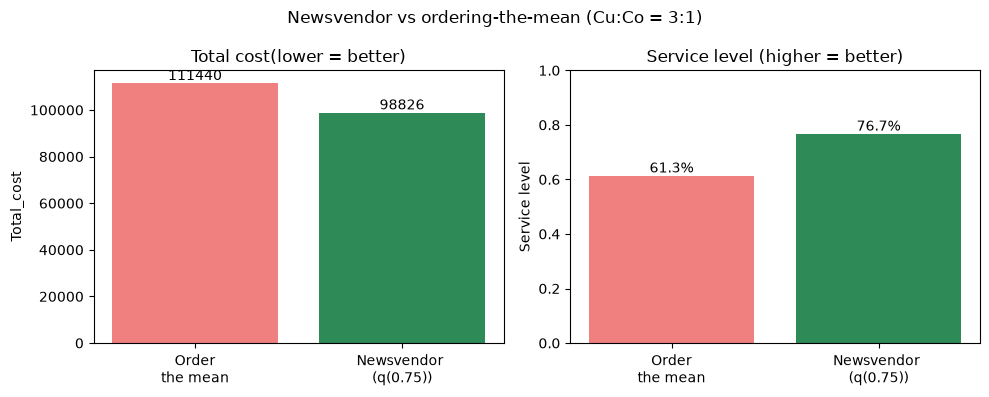

In [ ]:
fig, (ax1, ax2) = plt.subplots(1 ,2, figsize=(10, 4))

policies = ['Order\nthe mean', 'Newsvendor \n(q(0.75))']
costs = [cost_mean, cost_nv]
services = [service_level(order_mean, actual), service_level(order_newsvendor, actual)]

b1 = ax1.bar(policies, costs, color=['lightcoral', 'seagreen'])
ax1.set_ylabel("Total_cost"); ax1.set_title("Total cost(lower = better)")
for b, v in zip(b1, costs):
    ax1.text(b.get_x()+b.get_width()/2, v, f"{v:.0f}", ha='center', va='bottom')

b2 = ax2.bar(policies, services, color=['lightcoral', 'seagreen'])
ax2.set_ylabel("Service level"); ax2.set_title("Service level (higher = better)")
ax2.set_ylim(0, 1)
for b, v in zip(b2, services):
    ax2.text(b.get_x()+b.get_width()/2, v, f"{v:.1%}", ha='center', va='bottom')

plt.suptitle(f"Newsvendor vs ordering-the-mean (Cu:Co = 3:1)")
plt.tight_layout()
plt.savefig('../reports/figures/newsvendor_comparison.png', dpi=120)
plt.show()

## Explainability (SHAP)

Global feature importance and a single-prediction explanation — confirming the
model relies on recent demand and behaves sensibly.

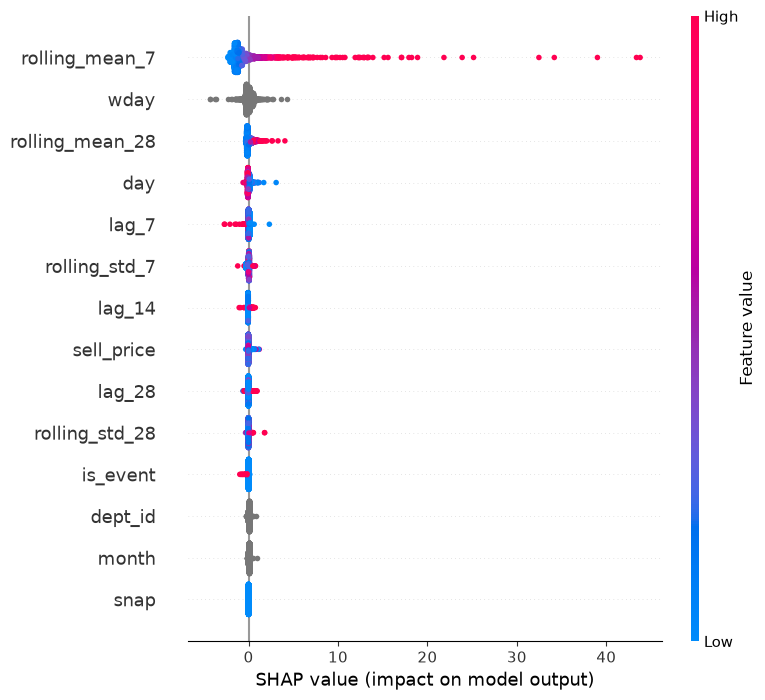

In [22]:

explainer = shap.TreeExplainer(mean_model)

# sampling the test set for speed using few thousand rows
sample= te.sample(n=2000, random_state=13)
X_sample = sample[features]
shap_values = explainer.shap_values(X_sample)

# Which global features drive the forcast 
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

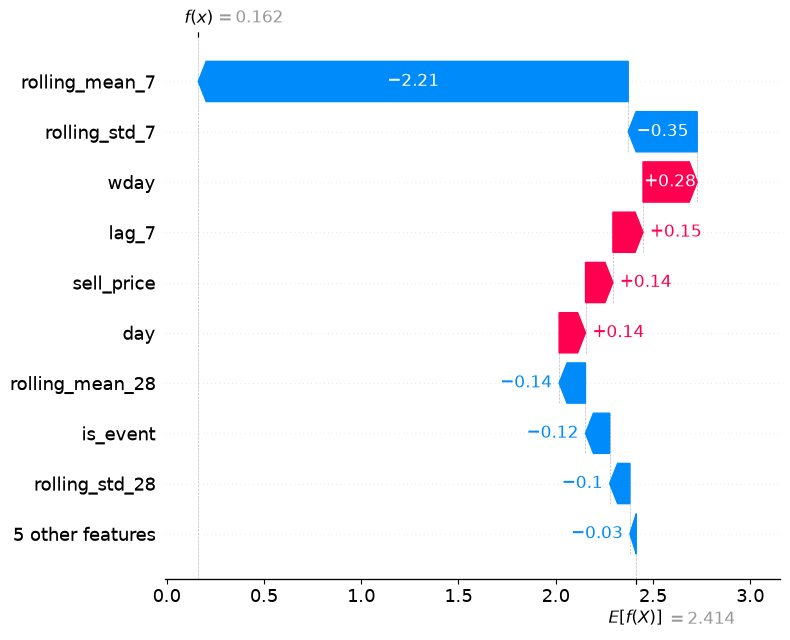

In [23]:
# --- Local: explain a single prediction ---
# Pick an interesting row — say one with non-trivial predicted demand
idx = 0  # first row of the sample; change to inspect others
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[idx],
    feature_names=features,
    show=False
)
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall.png', dpi=120, bbox_inches='tight')
plt.show()